# 06 — Batch Inference

Scores a small sample of "new applications" (raw rows with the target column dropped) using the latest trained model — exactly what `poetry run bnpl-risk predict-batch` does nightly. See `docs/inference.md`.

In [1]:
from pathlib import Path

from bnpl_credit_risk.data.loaders import BNPLDataLoader
from bnpl_credit_risk.pipelines.batch_inference_pipeline import run_batch_inference_pipeline
from bnpl_credit_risk.settings import get_settings, load_config

settings = get_settings()
config = load_config()
df = BNPLDataLoader(settings, config.data).load_raw()
applications = df.drop(columns=[config.data.target_column]).sample(30, random_state=1)
input_path = Path('../data/processed/notebook_applications_to_score.csv').resolve()
input_path.parent.mkdir(parents=True, exist_ok=True)
applications.to_csv(input_path, index=False)

2026-07-13 07:55:06.216 | INFO     | bnpl_credit_risk.data.loaders:load_raw:37 - Loaded raw dataset path=/Users/surelmanda/BNPL-Credit-Risk/data/raw/BNPL_CreditRisk_Dataset.csv rows=10345 columns=17


In [2]:
output_path = Path('../data/predictions/notebook_predictions.csv').resolve()
result = run_batch_inference_pipeline(config, settings, input_path=input_path, output_path=output_path)
result.n_scored, result.n_rejected, result.risk_band_distribution

2026-07-13 07:55:06.532 | INFO     | bnpl_credit_risk.inference.batch:run:49 - Loaded model version=2026-07-13_075445 for batch scoring


2026-07-13 07:55:06.535 | INFO     | bnpl_credit_risk.data.loaders:load_raw:37 - Loaded raw dataset path=/Users/surelmanda/BNPL-Credit-Risk/data/processed/notebook_applications_to_score.csv rows=30 columns=16


2026-07-13 07:55:06.541 | INFO     | bnpl_credit_risk.data.cleaning:clean:45 - Cleaned dataframe rows=30 columns=16


2026-07-13 07:55:06.547 | INFO     | bnpl_credit_risk.data.validation:validate:122 - Validation complete strategy=strict valid_rows=30 invalid_rows=0


2026-07-13 07:55:06.574 | INFO     | bnpl_credit_risk.inference.batch:run:93 - Batch inference complete: scored=30 rejected=0 output=/Users/surelmanda/BNPL-Credit-Risk/data/predictions/notebook_predictions.csv risk_bands={'Medium Risk': 11, 'High Risk': 8, 'Low Risk': 6, 'Very High Risk': 5}


(30,
 0,
 {'Medium Risk': 11, 'High Risk': 8, 'Low Risk': 6, 'Very High Risk': 5})

In [3]:
import pandas as pd

predictions = pd.read_csv(result.output_path)
predictions.head()

,user_id,default_probability,predicted_default,decision_threshold,risk_band,model_version,scoring_timestamp
0,2162,0.001621,0,0.048407,Low Risk,2026-07-13_075445,2026-07-13T07:55:06.572291
1,5597,0.681922,1,0.048407,High Risk,2026-07-13_075445,2026-07-13T07:55:06.572291
2,4366,0.323662,1,0.048407,Medium Risk,2026-07-13_075445,2026-07-13T07:55:06.572291
3,5310,0.894127,1,0.048407,Very High Risk,2026-07-13_075445,2026-07-13T07:55:06.572291
4,7118,0.705292,1,0.048407,High Risk,2026-07-13_075445,2026-07-13T07:55:06.572291


<Axes: title={'center': 'Risk band distribution'}, xlabel='risk_band'>

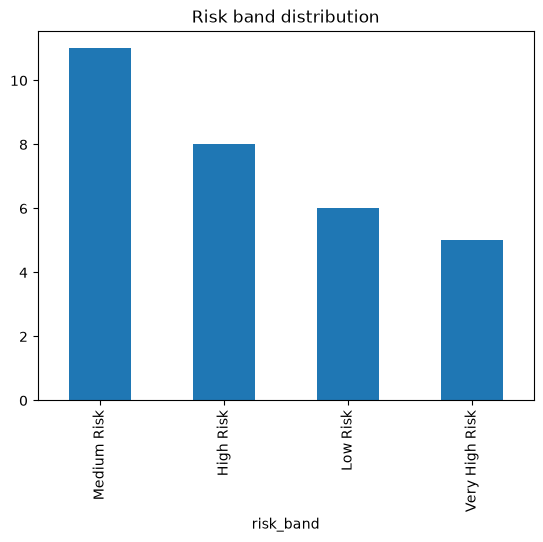

In [4]:
predictions['risk_band'].value_counts().plot(kind='bar', title='Risk band distribution')